# Comment on Martin Wolf on the "European Miracle"

Start with one of the simplest possible fundamentalist Malthusian models of human history:

* population growth is an increasing function of productivity and standard-of-living relative to subsistence.
* labor-productivity growth is a positive function of technological progress and a negative function of population growth that puts more pressure on the fixed stock of natural resources.
* technological progress is an increasing function of human population—because two heads are better than one—but a less than linear function—because of duplication of inventive effort, people stepping on one another's toes.
* And variables:
    * H, h: the level and the proportional growth rate of the value of the **H**uman ideas stock.
    * P, n: the level and the proportional growth rate of the **P**opulation.
    * y, g: the level and the proportional **G**rowth rate of productivity and income/standard of living.
    * $ \alpha, \sigma, \gamma, \beta, y_{sub} $: parameters: the two-heads-are-better-than-one coefficient, the stepping-on-toes coefficient, the salience of ideas vis-à-vis resources in determining productivity, the annual response of population growth to relative living standards, and the Malthusian subsistence level of productivity.

With the equations of the model being:

* $ h = \alpha P^{\sigma} $
* $ n = \beta \left( \frac{y - y_{sub}}{y_{sub}}  \right) $
* $ g = h - n/\gamma $

and add in some random shocks for verisimilitude...

Let us then fit, or rather "fit"—it is not a statistical fit—this model; over the period from the year -3000 development of writing, bronze, and the state to the year 200 classical-antiquity civilizational apogee; to my finger-estimate database of guesstimates about the structure of human economic history in the very long run:

<img src="images/2026-03-16-malthusian-fit-from--3000-to-200.png" />

The blue lines are our model simulation. The orange dots connected by straight lines are my guesstimate historical benchmarks, up to year 200

We have population growing from 45 million in the year -3000 to 260 million in the year 200. We have the tech level tracking in the trend by construction, and also fitting reasonably well in the curvature of the log series—over -3000 to 200, the assumption that technological progress is proportional to the square-root of population does remarkably well. We do have a couple of big demographic wiggles in the civilization arising out of the chance of the stochastic shocks imposed in the model: things like the Bronze Dark Age that we know happened but that the benchmarks do not capture.

So what then happens when we project actual history forward beyond the year 200? This:

<img src="images/2026-03-16-out-of-sample-vs-history.png" />

The first big thing we see in actual history after the year 200 is what we, these days, politely call the late-antiquity pause: it really does look like population falls from the year 200 to the year 800, without it being counted as a golden age of resource abundance. 

Some technology and a lot of social organization are lost between 200 and 800: in the western half of Eurasia, waves of barbarians, Romano-Persian wars, Muslim Arab conquests; in the eastern half, the fall of the Han the Three Kingdoms, the disaster of Yongjia, the sixteen kingdoms and northern and southern Dynasties, all capped off even after the Sui-Tang reunification by the disastrous An Lushan rebellion. 

By 800, however, things are somewhat more stabilized: Cœnwulf son of Cuthberht rules in Tamworth, Charles son of Pippin in Aachen, Irene widow of Leo IV the Isaurian in Constantinopolis, Harun Al-Rashid son of Al-Mahdi in Baghdad, Dharmapāla son of Gopāla in Pātaliputra, Dezong son of Suzong in Chang'an, and Kanmu son of Kōnin in Kyoto. The upward march of "civilization" resumes.

The late-antiquity pause, however, continues after 800 to leave a very definite mark. It is not until 1775 that the historical tech level of humanity catches up to that of the simulation, which avoids the late-antiquity pause but keeps on powering through. And, come 1775, the historical-benchmark population is still 20% below the simulated-model population: 800 million instead of a billion.

The major thing to note about the post-1775 world in the simple Malthusian model counterfactual simulation is this: nothing like the 1775-1875 industrial revolution century or the post-1875 modern economic growth era are on the horizon. Yes, the 1 billion population of the year 1775 is piling up technological knowledge at double the pace of what had been taking place back in the year 200 at the classical-antiquity apogee. But population growth at even 0.15% per year is more than enough to cause resource scarcity to offset the effect of that on living standards.

In [1]:
# initialization...

%matplotli
b inline

import pandas as pd             # i need the panda—the python panel data analysis—library
import numpy as np              # i need the numpy—the numerical python—library
import matplotlib.pyplot as plt # i need pyplot from matplotlib—the python plotting interface module within the python matlab-style plotting library
import random as rnd            # i need the standard random-number generation package


In [2]:
# read in my dataframe of guesstimates and guesses for finger exercises
# on the longest-run structure of human economic history

human_history_df = pd.read_feather("data/human_history_df.feather") # read in my dataframe

human_history_df.head(3) # check to see if everything is as expected

,year,population,income,world_product,year_diff,pop_growth,income_growth,tech_growth,ln_tech,tech_index,ln_population,ln_income,ln_tech_index
0,-73000,0.01,1500.0,15.0,NaN,NaN,NaN,NaN,0.000000,0.001829,-4.605170,7.31322,-6.303747
1,-48000,2.00,1500.0,3000.0,25000.0,0.000212,0.0,0.000106,2.649159,0.025872,0.693147,7.31322,-3.654588
2,-23000,3.00,1500.0,4500.0,25000.0,0.000016,0.0,0.000008,2.851891,0.031687,1.098612,7.31322,-3.451856


In [5]:
alpha = 0.000028                    # two-heads-are-better-than-one coefficient
sigma = 0.5                         # stepping-on-toes coefficient
gamma = 2                           # salience of ideas vis-à-vis resources in determining productivity
beta = 0.005                        # annual response of population growth to relative living standards
y_sub = 1100                        # subsistence level of productivity

initial_year = -3000                # historical year at which to start the exercise
final_year = 2025                   # historical year at which to end the exercise

initial_H = human_history_df.loc[human_history_df["year"] == initial_year, "tech_index"].iloc[0]
initial_P = human_history_df.loc[human_history_df["year"] == initial_year, "population"].iloc[0]
initial_y = human_history_df.loc[human_history_df["year"] == initial_year, "income"].iloc[0]

g = []                              # time-series list for productivity growth
n = []                              # time-series list for population growth
epsilon = []                        # uncorrelated random shocks to population
H = [initial_H]                     # time-series list for tech level, and initial tech level
P = [initial_P]                     # time-series list for population & labor force level, and initial level
y = [initial_y]                     # time-series list for productivity & living standard level, and initial level
h = [alpha * np.power(P[0], sigma)] # time-series list for rate of technology increase, and initial value
year = [initial_year]               # time-series list for year
 

for t in range(-initial_year + final_year):                     # loop through human history
    epsilon = epsilon + [rnd.normalvariate(0, 0.01)]           # calculate this year's population shock
    n = n + [beta * (y[t] - 1100)/1100 + epsilon[t]]           # calculate this year's population growth rate
    g = g + [h[t] - n[t]/gamma + rnd.normalvariate(0, 0.0002)] # calculate this year's productivity change
    h = h + [alpha *  np.power(P[t], sigma)]                   # calculate this year's technology change
    y = y + [y[t]*np.exp(g[t])]                                # calculate this year's productivity level
    P = P + [P[t]*np.exp(n[t])]                                # calculate this year's population level
    H = H + [H[t]*np.exp(h[t])]                                # calculate this year's technology level
    year = year + [t + initial_year - 1]                       # increment year

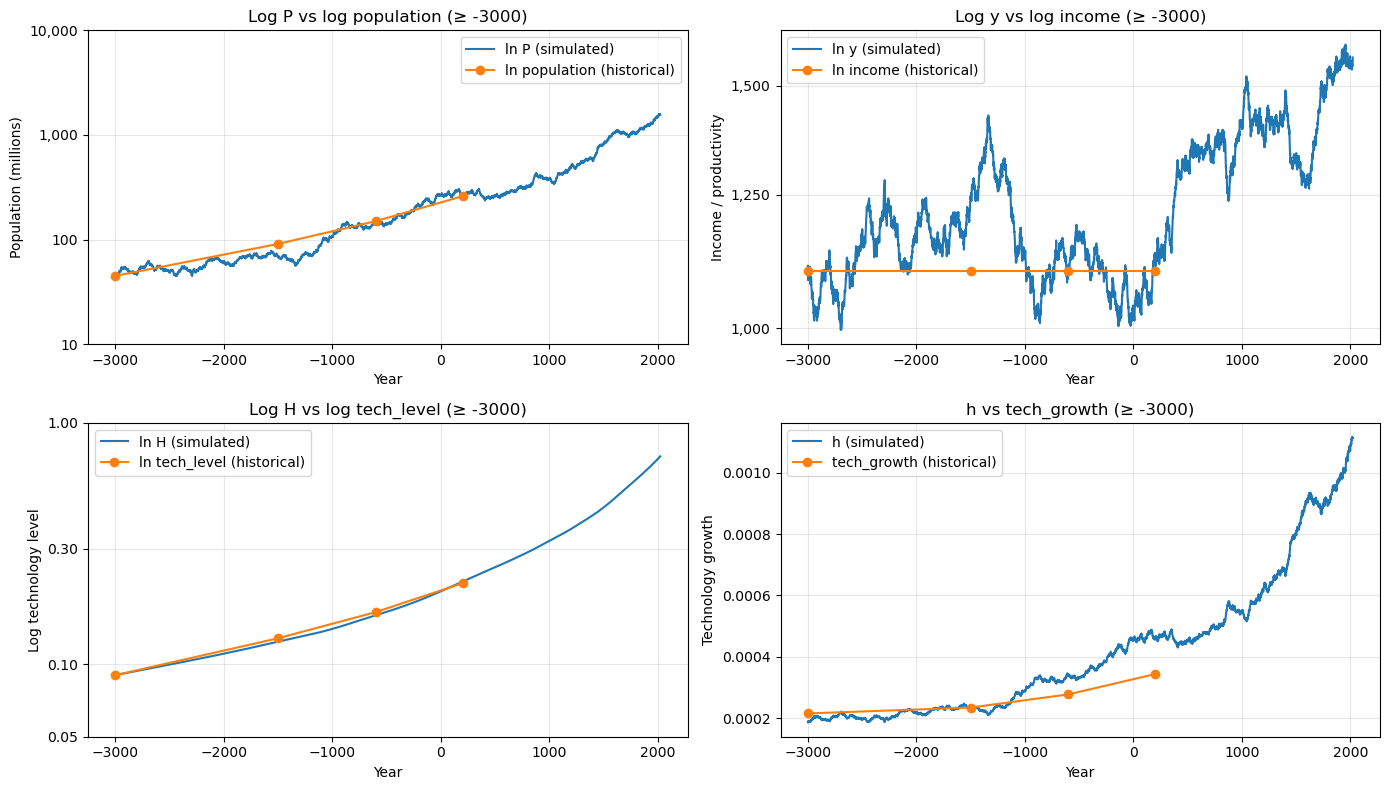

In [6]:
import numpy as np
import matplotlib.pyplot as plt



# Historical data restricted to [-3000, 200]
df = human_history_df.copy()
df["year"] = df["year"].astype(int)
mask   = (df["year"] >= -3000) & (df["year"] <= 200)
df_sub = df.loc[mask].copy()

years_df = df_sub["year"].values
pop_df   = df_sub["population"].values
inc_df   = df_sub["income"].values
tech_df  = df_sub["tech_index"].values
gtech_df = df_sub["tech_growth"].values

# Log transforms for positive levels only
# (we drop or mask nonpositive values to avoid -inf)
def safe_log(x):
    x = np.array(x, dtype=float)
    x[x <= 0] = np.nan
    return np.log(x)

lnP_sim   = safe_log(P_arr)
lny_sim   = safe_log(y_arr)
lnH_sim   = safe_log(H_arr)

lnP_data  = safe_log(pop_df)
lny_data  = safe_log(inc_df)
lnH_data  = safe_log(tech_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1,1) log P and log population vs year
ax = axes[0, 0]
ax.plot(year_arr, lnP_sim, color="tab:blue", label="ln P (simulated)")
ax.plot(years_df, lnP_data, color="tab:orange", marker="o",
        linestyle="-", label="ln population (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Population (millions)")
yticks_level = np.array([1e1, 1e2, 1e3, 1e4])
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.0f}" for val in yticks_level])
ax.set_title("Log P vs log population (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (1,2) log y and log income vs year
ax = axes[0, 1]
ax.plot(year_arr, lny_sim, color="tab:blue", label="ln y (simulated)")
ax.plot(years_df, lny_data, color="tab:orange", marker="o",
        linestyle="-", label="ln income (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Income / productivity")
yticks_level = np.array([1000, 1250, 1500])
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.0f}" for val in yticks_level])
ax.set_title("Log y vs log income (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,1) log H and log tech_level vs year
ax = axes[1, 0]
ax.plot(year_arr, lnH_sim, color="tab:blue", label="ln H (simulated)")
ax.plot(years_df, lnH_data, color="tab:orange", marker="o",
        linestyle="-", label="ln tech_level (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log technology level")
yticks_level = np.array([.05, .1, .3, 1], dtype=float)
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.2f}" for val in yticks_level])

ax.set_title("Log H vs log tech_level (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,2) h and tech_growth vs year (kept in levels: growth rates)
ax = axes[1, 1]
ax.plot(year_arr, h_arr, color="tab:blue", label="h (simulated)")
ax.plot(years_df, gtech_df, color="tab:orange", marker="o",
        linestyle="-", label="tech_growth (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Technology growth")
ax.set_title("h vs tech_growth (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


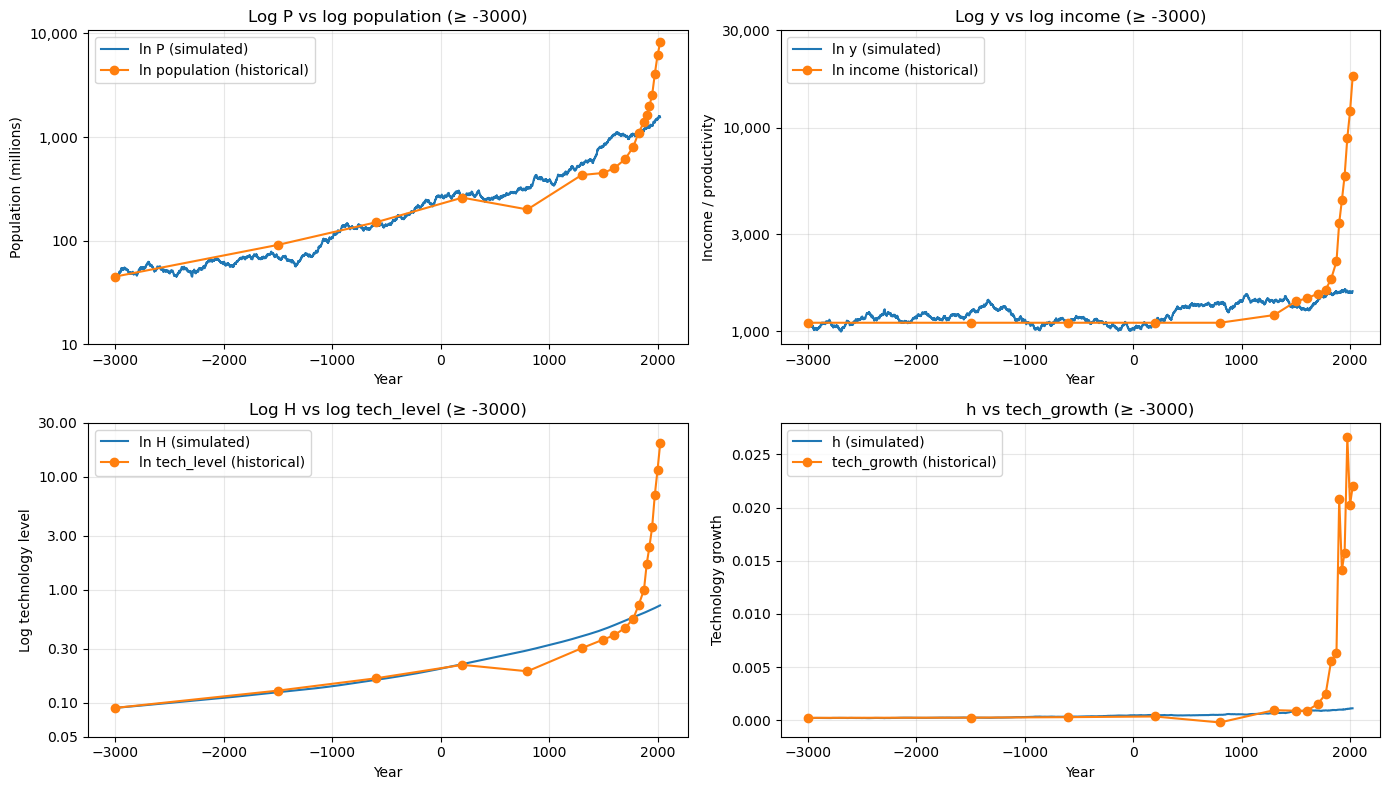

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation series
year_arr = np.array(year)
P_arr    = np.array(P)
y_arr    = np.array(y)
H_arr    = np.array(H)
h_arr    = np.array(h)

# Historical data restricted to [-3000, 2025]
df = human_history_df.copy()
df["year"] = df["year"].astype(int)
mask   = (df["year"] >= -3000) & (df["year"] <= 2025)
df_sub = df.loc[mask].copy()

years_df = df_sub["year"].values
pop_df   = df_sub["population"].values
inc_df   = df_sub["income"].values
tech_df  = df_sub["tech_index"].values
gtech_df = df_sub["tech_growth"].values

# Log transforms for positive levels only
# (we drop or mask nonpositive values to avoid -inf)
def safe_log(x):
    x = np.array(x, dtype=float)
    x[x <= 0] = np.nan
    return np.log(x)

lnP_sim   = safe_log(P_arr)
lny_sim   = safe_log(y_arr)
lnH_sim   = safe_log(H_arr)

lnP_data  = safe_log(pop_df)
lny_data  = safe_log(inc_df)
lnH_data  = safe_log(tech_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1,1) log P and log population vs year
ax = axes[0, 0]
ax.plot(year_arr, lnP_sim, color="tab:blue", label="ln P (simulated)")
ax.plot(years_df, lnP_data, color="tab:orange", marker="o",
        linestyle="-", label="ln population (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Population (millions)")
yticks_level = np.array([1e1, 1e2, 1e3, 1e4])
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.0f}" for val in yticks_level])
ax.set_title("Log P vs log population (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (1,2) log y and log income vs year
ax = axes[0, 1]
ax.plot(year_arr, lny_sim, color="tab:blue", label="ln y (simulated)")
ax.plot(years_df, lny_data, color="tab:orange", marker="o",
        linestyle="-", label="ln income (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Income / productivity")
yticks_level = np.array([1000, 3000, 10000, 30000])
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.0f}" for val in yticks_level])

ax.set_title("Log y vs log income (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,1) log H and log tech_level vs year
ax = axes[1, 0]
ax.plot(year_arr, lnH_sim, color="tab:blue", label="ln H (simulated)")
ax.plot(years_df, lnH_data, color="tab:orange", marker="o",
        linestyle="-", label="ln tech_level (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log technology level")
yticks_level = np.array([.05, .1, .3, 1, 3, 10, 30], dtype=float)
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.2f}" for val in yticks_level])

ax.set_title("Log H vs log tech_level (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,2) h and tech_growth vs year (kept in levels: growth rates)
ax = axes[1, 1]
ax.plot(year_arr, h_arr, color="tab:blue", label="h (simulated)")
ax.plot(years_df, gtech_df, color="tab:orange", marker="o",
        linestyle="-", label="tech_growth (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Technology growth")
ax.set_title("h vs tech_growth (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


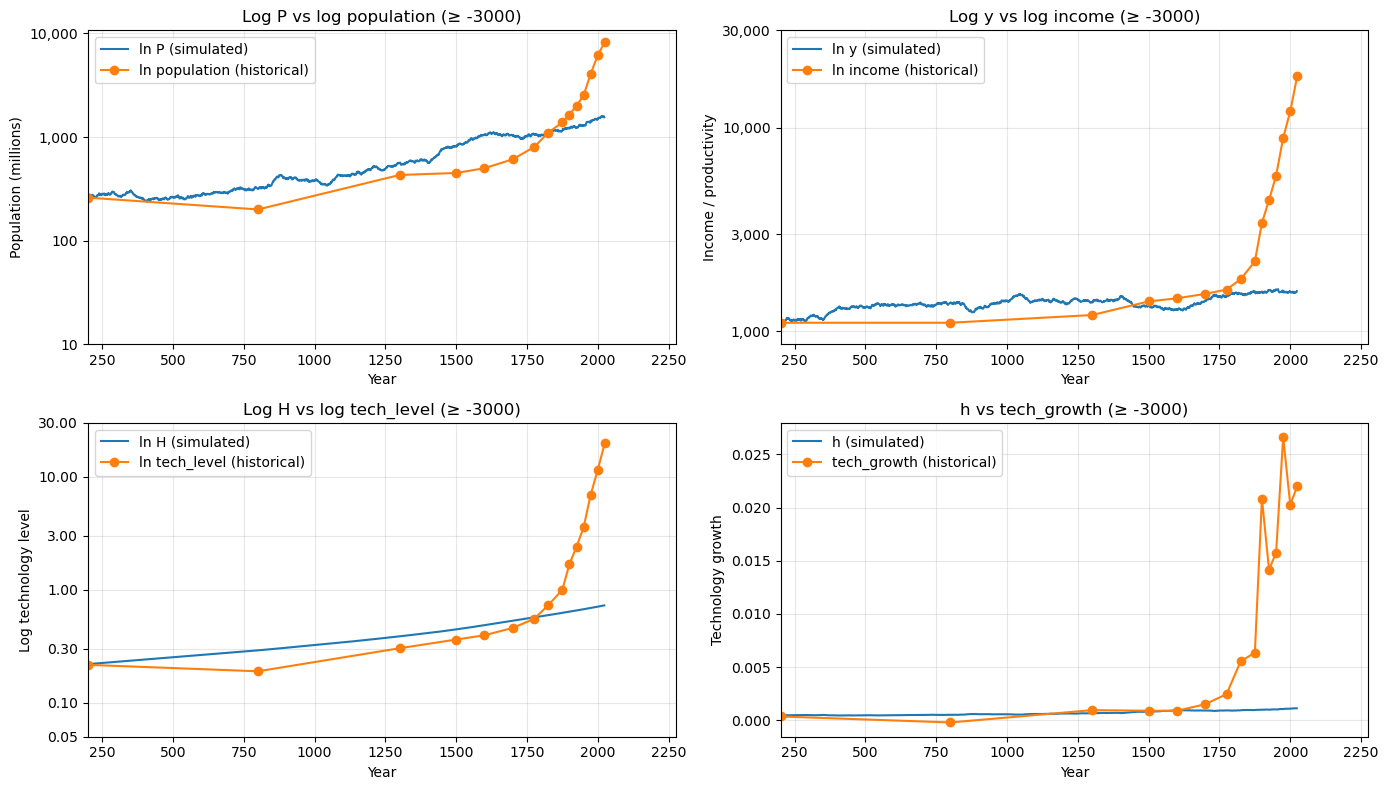

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation series
year_arr = np.array(year)
P_arr    = np.array(P)
y_arr    = np.array(y)
H_arr    = np.array(H)
h_arr    = np.array(h)

# Historical data restricted to [-3000, 2025]
df = human_history_df.copy()
df["year"] = df["year"].astype(int)
mask   = (df["year"] >= -3000) & (df["year"] <= 2025)
df_sub = df.loc[mask].copy()

years_df = df_sub["year"].values
pop_df   = df_sub["population"].values
inc_df   = df_sub["income"].values
tech_df  = df_sub["tech_index"].values
gtech_df = df_sub["tech_growth"].values

# Log transforms for positive levels only
# (we drop or mask nonpositive values to avoid -inf)
def safe_log(x):
    x = np.array(x, dtype=float)
    x[x <= 0] = np.nan
    return np.log(x)

lnP_sim   = safe_log(P_arr)
lny_sim   = safe_log(y_arr)
lnH_sim   = safe_log(H_arr)

lnP_data  = safe_log(pop_df)
lny_data  = safe_log(inc_df)
lnH_data  = safe_log(tech_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1,1) log P and log population vs year
ax = axes[0, 0]
ax.plot(year_arr, lnP_sim, color="tab:blue", label="ln P (simulated)")
ax.plot(years_df, lnP_data, color="tab:orange", marker="o",
        linestyle="-", label="ln population (historical)")
ax.set_xlabel("Year")
ax.set_xlim(left=200)
ax.set_ylabel("Population (millions)")
yticks_level = np.array([1e1, 1e2, 1e3, 1e4])
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.0f}" for val in yticks_level])
ax.set_title("Log P vs log population (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (1,2) log y and log income vs year
ax = axes[0, 1]
ax.plot(year_arr, lny_sim, color="tab:blue", label="ln y (simulated)")
ax.plot(years_df, lny_data, color="tab:orange", marker="o",
        linestyle="-", label="ln income (historical)")
ax.set_xlabel("Year")
ax.set_xlim(left=200)
ax.set_ylabel("Income / productivity")
yticks_level = np.array([1000, 3000, 10000, 30000])
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.0f}" for val in yticks_level])

ax.set_title("Log y vs log income (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,1) log H and log tech_level vs year
ax = axes[1, 0]
ax.plot(year_arr, lnH_sim, color="tab:blue", label="ln H (simulated)")
ax.plot(years_df, lnH_data, color="tab:orange", marker="o",
        linestyle="-", label="ln tech_level (historical)")
ax.set_xlabel("Year")
ax.set_xlim(left=200)
ax.set_ylabel("Log technology level")
yticks_level = np.array([.05, .1, .3, 1, 3, 10, 30], dtype=float)
yticks_log   = np.log(yticks_level)
ax.set_yticks(yticks_log)
ax.set_yticklabels([f"{val:,.2f}" for val in yticks_level])

ax.set_title("Log H vs log tech_level (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,2) h and tech_growth vs year (kept in levels: growth rates)
ax = axes[1, 1]
ax.plot(year_arr, h_arr, color="tab:blue", label="h (simulated)")
ax.plot(years_df, gtech_df, color="tab:orange", marker="o",
        linestyle="-", label="tech_growth (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Technology growth")
ax.set_title("h vs tech_growth (≥ -3000)")
ax.set_xlim(left=200)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


In [8]:
human_history_df


,year,population,income,world_product,year_diff,pop_growth,income_growth,tech_growth,ln_tech,tech_index,ln_population,ln_income,ln_tech_index
0,-73000,0.01,1500.0,15.0,NaN,NaN,NaN,NaN,0.000000,0.001829,-4.605170,7.313220,-6.303747
1,-48000,2.00,1500.0,3000.0,25000.0,0.000212,0.000000,0.000106,2.649159,0.025872,0.693147,7.313220,-3.654588
2,-23000,3.00,1500.0,4500.0,25000.0,0.000016,0.000000,0.000008,2.851891,0.031687,1.098612,7.313220,-3.451856
3,-13000,4.00,1500.0,6000.0,10000.0,0.000029,0.000000,0.000014,2.995732,0.036589,1.386294,7.313220,-3.308015
4,-8000,5.00,1500.0,7500.0,5000.0,0.000045,0.000000,0.000022,3.107304,0.040907,1.609438,7.313220,-3.196443
5,-5000,19.00,1100.0,20900.0,3000.0,0.000445,-0.000103,0.000119,3.464650,0.058478,2.944439,7.003065,-2.839097
6,-3000,45.00,1100.0,49500.0,2000.0,0.000431,0.000000,0.000216,3.895761,0.089996,3.806662,7.003065,-2.407986
7,-1500,91.00,1100.0,100100.0,1500.0,0.000469,0.000000,0.000235,4.247860,0.127979,4.510860,7.003065,-2.055887
8,-600,150.00,1100.0,165000.0,900.0,0.000555,0.000000,0.000278,4.497748,0.164310,5.010635,7.003065,-1.805999
9,200,260.00,1100.0,286000.0,800.0,0.000688,0.000000,0.000344,4.772771,0.216324,5.560682,7.003065,-1.530976


## Modeling Rates of Technological Progress

It was, I think, in 1985 back when I was still a graduate student that I really became aware of the "two heads are better than one" argument as I watched Paul Romer present a piece of his dissertation—a piece that had already been accepted by and was about to be published in the _Journal of Political Economy_. 

* Romer, Paul M. 1986. “Increasing Returns & Long-Run Growth.” _Journal of Political Economy_ 94(5): 1002–37. <<https://paulromer.net/speeding-up-and-missed-opportunities-evidence/IncreasingReturns.pdf>>.
* Kremer, Michael. 1993. “Population Growth & Technological Change: One Million B.C. to 1990.” _Quarterly Journal of Economics_ 108 (3): 681–716. <<https://faculty.econ.ucdavis.edu/faculty/gclark/210a/readings/kremer1993.pdf>>>
* Diamond, Jared. 1997. _Guns, Germs, and Steel: The Fates of Human Societies_. New York: W. W. Norton. <<https://dn721503.ca.archive.org/0/items/fp_Jared_Diamond-Guns_Germs_and_Steel/Jared_Diamond-Guns_Germs_and_Steel.pdf>>.

Paul did something that, in retrospect, is stunningly simple: it took the old production function, pulled ideas out of the undifferentiated capital aggregate, and insisted that they were different—non-rival, accumulating, and capable of generating increasing returns at the social level even when private firms still faced diminishing returns.

Once you see that, you cannot unsee it. Non-rivalry means that if I have the blueprint for the Watt steam engine or for CRISPR, my using it does not prevent you from using it as well. We can both plug the same idea into our production lines, and the marginal cost of your adoption is, essentially, zero. A world made up only of rival goods—land, raw labor, iron ore—grinds against diminishing returns and the Malthusian devil. Add a stock of non-rival ideas that can be copied and recombined, and suddenly the growth rate of knowledge, ￼, can be written, in the simplest possible reduced form, as proportional to the number of brains available to think: ￼.

That is where Michael Kremer enters, walking onstage from the long run of one million B.C. to 1990. Kremer basically says: take Romer’s “two heads are better than one” literally and push it back nearly to Homo erectus with a sharp stick. If ideas are non-rival, more people mean more potential inventors. Combine that with a Malthusian world in which population is limited by technology, and you get the striking empirical regularity Kremer documents: for most of human history, the growth rate of population is roughly proportional to the level of population. More people → more ideas → higher carrying capacity → more people. A feedback loop, not a steady state.

Jared Diamond gives us the spatial counterpart to this temporal story. Geography, crops, domesticable animals, and continental axes determine where dense populations, cities, and written traditions can form. Those are precisely the institutions that let a society store, copy, and recombine non-rival ideas at scale. An Andean herder and a Fertile Crescent scribe are not different in cognitive capacity; what is different is how many other heads their ideas can bump up against, how many previous ideas they can draw on, and how cheaply those ideas can be transmitted.

Put Romer, Kremer, and Diamond together and you get a macrostructure of human history that looks very much like the hockey-stick plots in your notebook: for millennia, population, globa income, and a very crude tech index creep upward as the non-rival idea engine runs slowly in small, partially isolated populations; then the commercial-imperial and industrial eras abruptly knit those populations into a single “anthology intelligence” with vastly expanded means of R&D, and the growth rate of technology jumps by an order of magnitude or more—and keeps on growing.

The true scarce resource in the long run is not stuff; rather, it has been arrangements—non-rival patterns of information and organization that let us get more out of the same rival inputs. History’s hinge points are the moments when we change how many heads can share how many ideas how fast.

Now there is "stepping on toes": two heads are not twice as good as one

All that suggests a very simple model of technological change as a function of world population:

$$
\begin{equation}
\frac{\dot H_t}{H_t} =  \alpha P_t^\sigma
\end{equation}
$$

Where H is our index of technology—human ideas—and P our estimate of population, and alpha and sigma are parameters. Let's take sigma = 0.5, and then roll with this

Now you can immediately start complicating this "two heads are better than one" story further. But let's roll with this: